# STAT 654 - CREDIT CARD SPENDING ANALYSIS, PREDICTIONS AND RECOMMENDATIONS

In [36]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.parser import parse as dparse
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import IFrame

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (r2_score, mean_absolute_error, accuracy_score, classification_report, f1_score)
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from prophet import Prophet
import holidays


# Descriptive Analysis

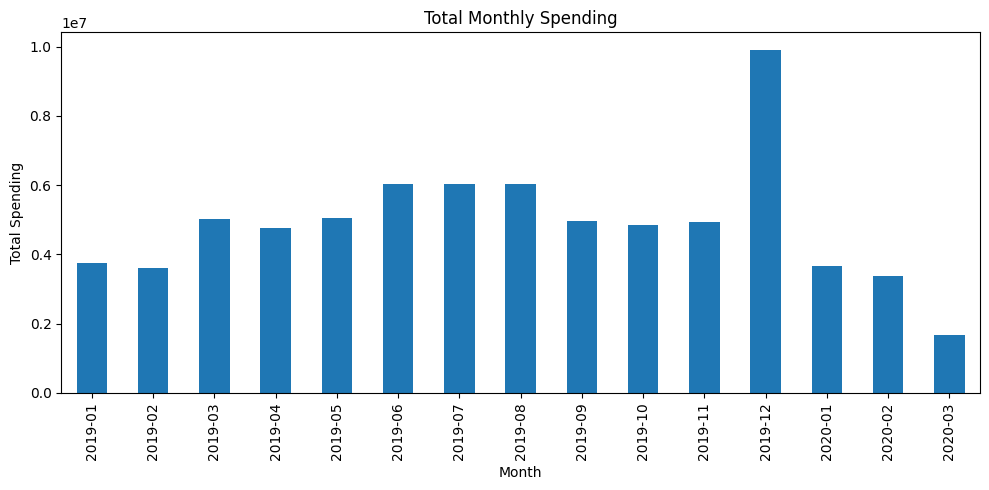

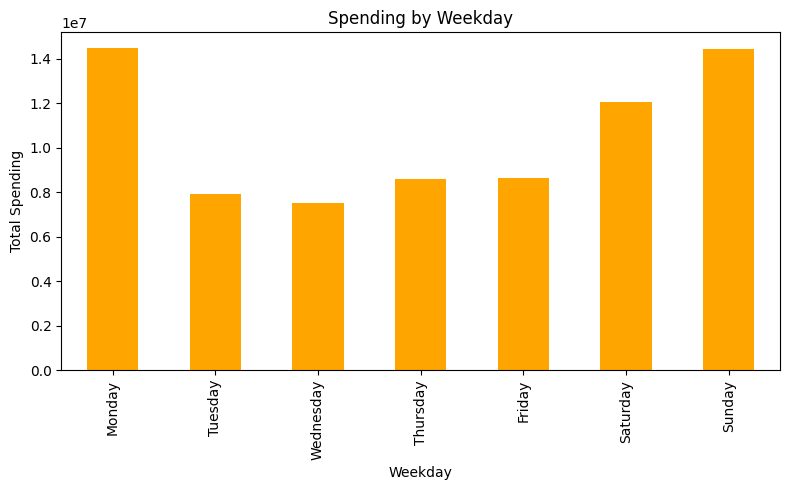

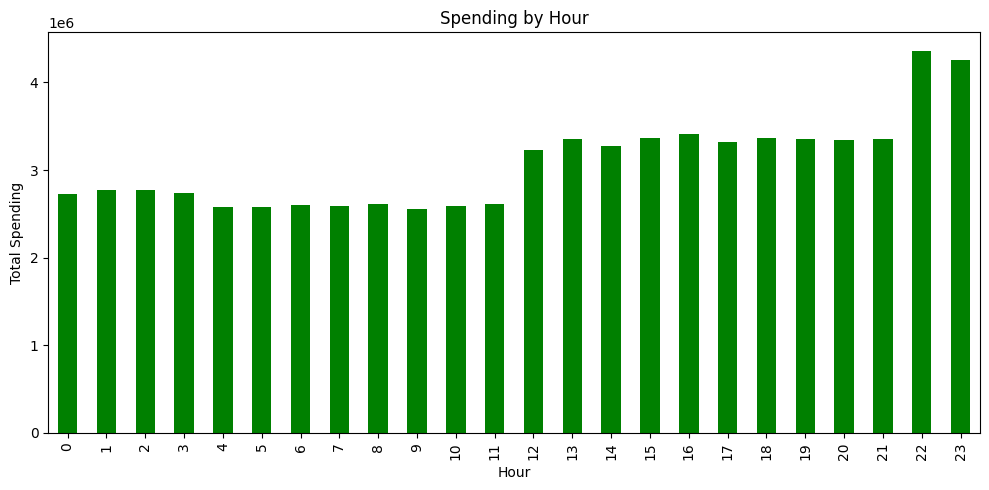

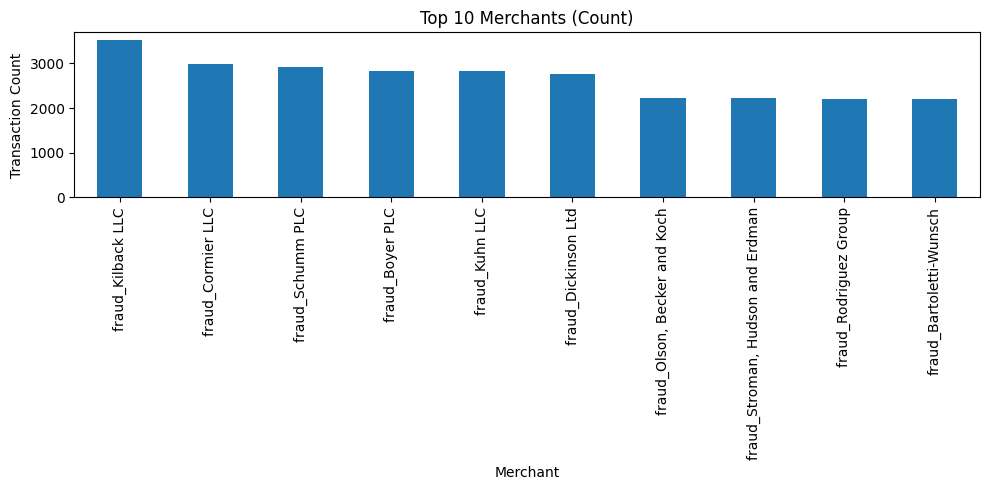

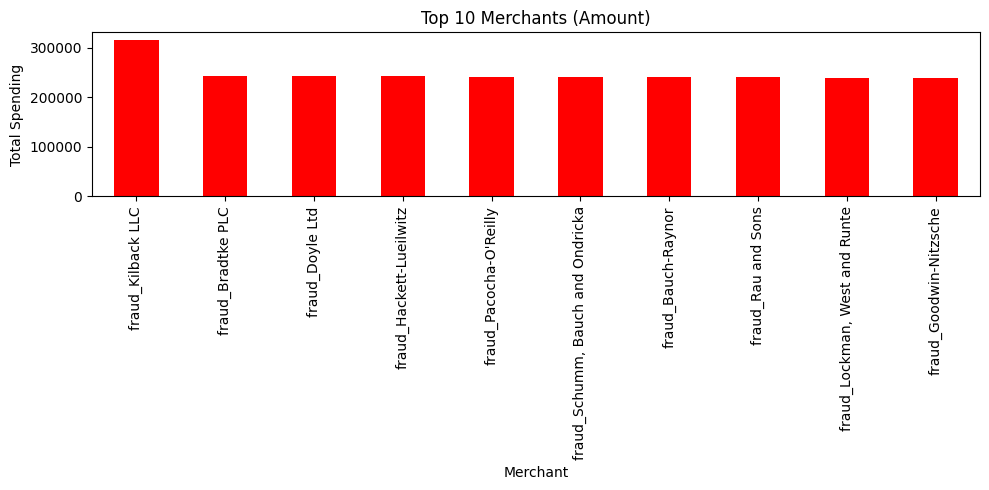

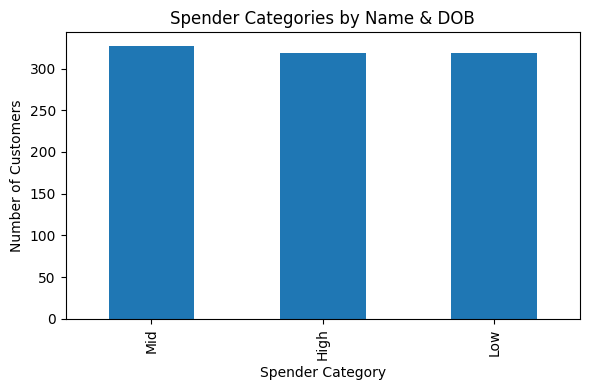

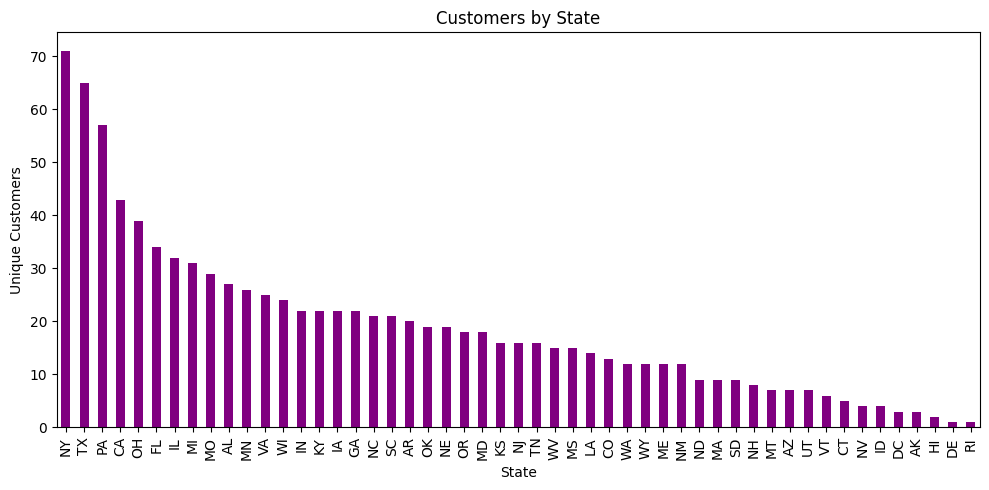

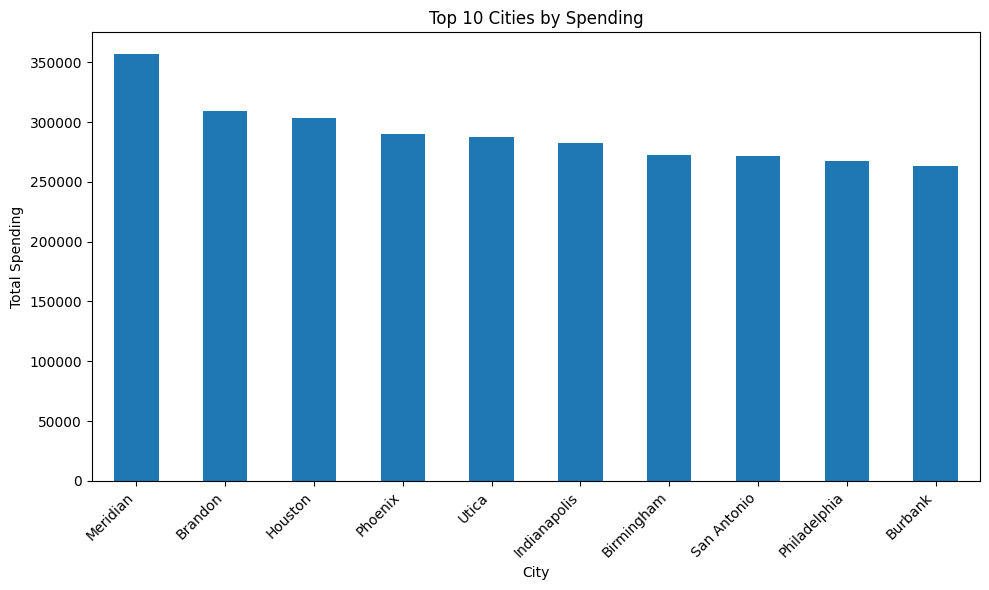

In [37]:
# Read Data
df = pd.read_csv("/Users/akibmahmud/Library/CloudStorage/OneDrive-TexasA&MUniversity/Spring 2025/STAT 654/Term Project/credit_card_transactions.csv",
    dtype={"trans_date_trans_time": "string"})

def parse_mixed(dt_str):
    try:
        return pd.to_datetime(dt_str, format="%m/%d/%Y %I:%M:%S %p")
    except ValueError:
        pass
    try:
        return pd.to_datetime(dt_str, format="%m/%d/%y %H:%M")
    except ValueError:
        pass
    return dparse(dt_str)

df["trans_date_trans_time"] = df["trans_date_trans_time"].apply(parse_mixed)
df['amt'] = pd.to_numeric(df['amt'], errors='coerce')

df.dropna(subset=['amt','trans_date_trans_time'], inplace=True)

df_desc = df

# ─── Total Monthly Spending
df_desc['Month'] = df_desc['trans_date_trans_time'].dt.to_period('M')
monthly_spending = df_desc.groupby('Month')['amt'].sum().sort_index()

plt.figure(figsize=(10,5))
monthly_spending.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Total Spending')
plt.title('Total Monthly Spending')
plt.tight_layout()
plt.show()

# ─── Spending by Weekday
df_desc['Weekday'] = df_desc['trans_date_trans_time'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_spending = df_desc.groupby('Weekday')['amt'].sum().reindex(weekday_order)

plt.figure(figsize=(8,5))
weekday_spending.plot(kind='bar', color='orange')
plt.xlabel('Weekday')
plt.ylabel('Total Spending')
plt.title('Spending by Weekday')
plt.tight_layout()
plt.show()

# ─── Hourly Spending Analysis
df_desc['Hour'] = df_desc['trans_date_trans_time'].dt.hour
hourly_spending = df_desc.groupby('Hour')['amt'].sum().sort_index()

plt.figure(figsize=(10,5))
hourly_spending.plot(kind='bar', color='green')
plt.xlabel('Hour')
plt.ylabel('Total Spending')
plt.title('Spending by Hour')
plt.tight_layout()
plt.show()

# ─── Top Merchants
top_merchant_count = df_desc['merchant'].value_counts().head(10)
top_merchant_amount = df_desc.groupby('merchant')['amt'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_merchant_count.plot(kind='bar')
plt.xlabel('Merchant')
plt.ylabel('Transaction Count')
plt.title('Top 10 Merchants (Count)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
top_merchant_amount.plot(kind='bar', color='red')
plt.xlabel('Merchant')
plt.ylabel('Total Spending')
plt.title('Top 10 Merchants (Amount)')
plt.tight_layout()
plt.show()

# ─── Customer Segmentation
df_desc['customer_id'] = (
    df_desc['first'].str.strip() + '_' +
    df_desc['last'].str.strip() + '_' +
    df_desc['dob'].astype(str)
)
customer_spending = df_desc.groupby('customer_id')['amt'].sum()
low_thr  = customer_spending.quantile(0.33)
high_thr = customer_spending.quantile(0.67)

def categorize(x):
    if x <= low_thr:   return 'Low'
    if x <= high_thr:  return 'Mid'
    return 'High'

customer_categories = customer_spending.map(categorize).value_counts()

plt.figure(figsize=(6,4))
customer_categories.plot(kind='bar')
plt.xlabel('Spender Category')
plt.ylabel('Number of Customers')
plt.title('Spender Categories by Name & DOB')
plt.tight_layout()
plt.show()

# ─── People by State
people_by_state = df_desc.groupby('state')['customer_id'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10,5))
people_by_state.plot(kind='bar', color='purple')
plt.xlabel('State')
plt.ylabel('Unique Customers')
plt.title('Customers by State')
plt.tight_layout()
plt.show()

# ─── Top 10 Cities by Spending
top_cities_desc = df_desc.groupby('city')['amt'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_cities_desc.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Total Spending')
plt.title('Top 10 Cities by Spending')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ─── Heatmap of Spending Across States
state_spending = df_desc.groupby("state")["amt"].sum().reset_index()

fig = px.choropleth(
    state_spending,
    locations="state",
    locationmode="USA-states",
    color="amt",
    title="Total Spending by State",
    color_continuous_scale="Viridis"
)
fig.update_geos(scope="usa", visible=False)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

html_file = "Total_Spending_by_state.html"
IFrame(html_file, width=800, height=600)


# LSTM

Subsampled to 965 customers, 1048575 transactions
Using 909 customers with ≥60 days
X shape: (382661, 7, 1384), y shape: (382661, 7)
Best val R²: 0.2948985695838928
Best params: {'lr': 0.001, 'hidden': 128, 'layers': 2, 'dropout': 0.0}
LSTM Test R²: 0.4849, MAE: 0.0398


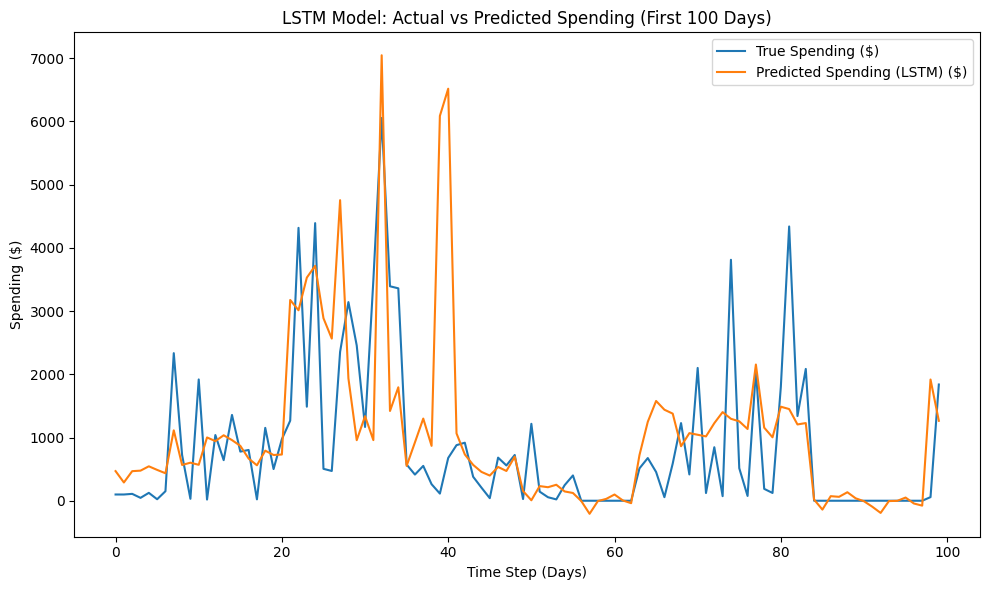

In [38]:
# ─── Customer Segmentation
df['customer_id'] = df['first'].str.strip() + '_' + df['last'].str.strip() + '_' + df['dob'].astype(str)
df["dob"] = pd.to_datetime(df["dob"], format="%m/%d/%Y", errors="coerce")
df['age'] = df['dob'].apply(lambda x: datetime.now().year - x.year if pd.notnull(x) else np.nan)

# ─── Subsample Customers (for model development)
np.random.seed(42)
unique_customers = df['customer_id'].unique()
n_customers = int(len(unique_customers) * 1)  # use 1 for 100% or 0.25 for 25%
sample_customers = np.random.choice(unique_customers, size=n_customers, replace=False)
df = df[df['customer_id'].isin(sample_customers)].copy()
print(f"Subsampled to {n_customers} customers, {len(df)} transactions")

# ─── Aggregate Daily Spending
daily = df.groupby(['customer_id', df['trans_date_trans_time'].dt.date])['amt']\
          .sum().reset_index()
daily.columns = ['customer_id','date','total_spent']
daily['date'] = pd.to_datetime(daily['date'])

# ─── Calendar & Demographic Features
us_holidays = holidays.US()
def add_time_features(d):
    d['day_of_week'] = d['date'].dt.dayofweek
    d['is_weekend'] = (d['day_of_week'] >= 5).astype(float)
    d['is_payday']  = d['date'].dt.day.isin([1,15]).astype(float)
    d['is_holiday'] = d['date'].isin(us_holidays).astype(float)
    return d

user_info = df[['customer_id','age','job','city']].drop_duplicates('customer_id')
cities = df['city'].value_counts().index
user_info['city_grouped'] = user_info['city'].where(user_info['city'].isin(cities),'Other')

users = daily['customer_id'].unique()
processed = []
for uid in users:
    u = (daily[daily['customer_id']==uid]
         .set_index('date')
         .asfreq('D', fill_value=0)
         .reset_index())
    demo = user_info[user_info['customer_id']==uid].iloc[0]
    u['age'] = demo['age']
    u['job'] = demo['job']
    u['city_grouped'] = demo['city_grouped']
    u = add_time_features(u)
    processed.append(u)
full_df = pd.concat(processed, ignore_index=True)

# ─── Encode & Normalize
full_df['scaled_spent'] = 0.0
for uid in users:
    mask = full_df['customer_id']==uid
    scaler = MinMaxScaler()
    full_df.loc[mask,'scaled_spent'] = scaler.fit_transform(
        full_df.loc[mask,['total_spent']].values
    ).flatten()

dow_ohe  = pd.get_dummies(full_df['day_of_week'],  prefix='dow')
job_ohe  = pd.get_dummies(full_df['job'],         prefix='job')
city_ohe = pd.get_dummies(full_df['city_grouped'],prefix='city')
full_df = pd.concat([full_df,dow_ohe,job_ohe,city_ohe],axis=1)

feature_cols = (
    ['scaled_spent','age','is_weekend','is_payday','is_holiday']
    + list(dow_ohe.columns)
    + list(job_ohe.columns)
    + list(city_ohe.columns)
)
for c in feature_cols:
    full_df[c] = pd.to_numeric(full_df[c],errors='coerce').fillna(0.0)

# ─── Filter by Transaction History Length 
min_days = 60
counts = full_df.groupby('customer_id')['date'].nunique()
eligible = counts[counts>=min_days].index
full_df = full_df[full_df['customer_id'].isin(eligible)].copy()
users = eligible.tolist()
print(f"Using {len(users)} customers with ≥{min_days} days")

# ─── Sequence Generation
seq_len, output_size = 7, 7
X_list, y_list = [], []
for uid in users:
    u = full_df[full_df['customer_id']==uid].sort_values('date')
    data = u[feature_cols].values.astype(np.float32)
    tgt  = u['scaled_spent'].values.astype(np.float32)
    for i in range(len(u)-seq_len-output_size+1):
        X_list.append(data[i:i+seq_len])
        y_list.append(tgt[i+seq_len:i+seq_len+output_size])
X = np.stack(X_list)
y = np.stack(y_list)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# ─── Train/Val/Test Split 
X_tr_full, X_test, y_tr_full, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_tr_full,y_tr_full,test_size=0.25,random_state=42)

def make_loader(Xa,ya,bs=64,shuffle=False):
    return DataLoader(TensorDataset(torch.from_numpy(Xa),torch.from_numpy(ya)),batch_size=bs,shuffle=shuffle)

train_loader = make_loader(X_train,y_train,shuffle=True)
val_loader   = make_loader(X_val,  y_val)
test_loader  = make_loader(X_test, y_test)

# ─── LSTM + Hyperparameter Tuning
class SpendingLSTM(nn.Module):
    def __init__(self,input_size,hidden_size,output_size,num_layers,dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size,hidden_size,num_layers=num_layers,
                            dropout=(dropout if num_layers>1 else 0),
                            batch_first=True)
        self.lin  = nn.Linear(hidden_size,output_size)
    def forward(self,x):
        out,_ = self.lstm(x)
        return self.lin(out[:,-1,:])

best_score, best_params = -np.inf, None
param_grid = {
    'lr':      [1e-3,5e-4,1e-4],
    'hidden':  [64,128],
    'layers':  [1,2],
    'dropout': [0.0,0.2]
}

for lr in param_grid['lr']:
    for hs in param_grid['hidden']:
        for nl in param_grid['layers']:
            for dr in param_grid['dropout']:
                model = SpendingLSTM(X.shape[2],hs,output_size,nl,dr)
                opt   = torch.optim.Adam(model.parameters(),lr=lr)
                loss_fn = nn.MSELoss()
                model.train()
                for _ in range(5):
                    for xb,yb in train_loader:
                        opt.zero_grad(); loss_fn(model(xb),yb).backward(); opt.step()
                model.eval()
                preds, trues = [],[]
                with torch.no_grad():
                    for xb,yb in val_loader:
                        preds.append(model(xb).numpy()); trues.append(yb.numpy())
                p=np.vstack(preds).flatten(); t=np.vstack(trues).flatten()
                score = r2_score(t,p)
                if score>best_score:
                    best_score, best_params = score, {'lr':lr,'hidden':hs,'layers':nl,'dropout':dr}
print("Best val R²:",best_score)
print("Best params:",best_params)

# ─── Evaluate LSTM
model = SpendingLSTM(X.shape[2],best_params['hidden'],output_size,best_params['layers'],best_params['dropout'])
opt = torch.optim.Adam(model.parameters(),lr=best_params['lr'])
loss_fn = nn.MSELoss()
combined_loader = make_loader(np.vstack((X_train,X_val)),np.vstack((y_train,y_val)),shuffle=True)
model.train()
for _ in range(20):
    for xb,yb in combined_loader:
        opt.zero_grad(); loss_fn(model(xb),yb).backward(); opt.step()
model.eval()
preds, trues = [],[]
with torch.no_grad():
    for xb,yb in test_loader:
        preds.append(model(xb).numpy()); trues.append(yb.numpy())
p_test = np.vstack(preds).flatten(); t_test = np.vstack(trues).flatten()
r2 = r2_score(t_test,p_test); mae = mean_absolute_error(t_test,p_test)
print(f"LSTM Test R²: {r2:.4f}, MAE: {mae:.4f}")

# ─── Visualize LSTM Test Predictions
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(full_df[['total_spent']])

p_test_dollars = scaler.inverse_transform(p_test.reshape(-1, 1)).flatten()
t_test_dollars = scaler.inverse_transform(t_test.reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 6))
plt.plot(t_test_dollars[:100], label='True Spending ($)')
plt.plot(p_test_dollars[:100], label='Predicted Spending (LSTM) ($)')
plt.title('LSTM Model: Actual vs Predicted Spending (First 100 Days)')
plt.xlabel('Time Step (Days)')
plt.ylabel('Spending ($)')
plt.legend()
plt.tight_layout()
plt.show()

# PROPHET 

05:07:21 - cmdstanpy - INFO - Chain [1] start processing
05:07:21 - cmdstanpy - INFO - Chain [1] done processing


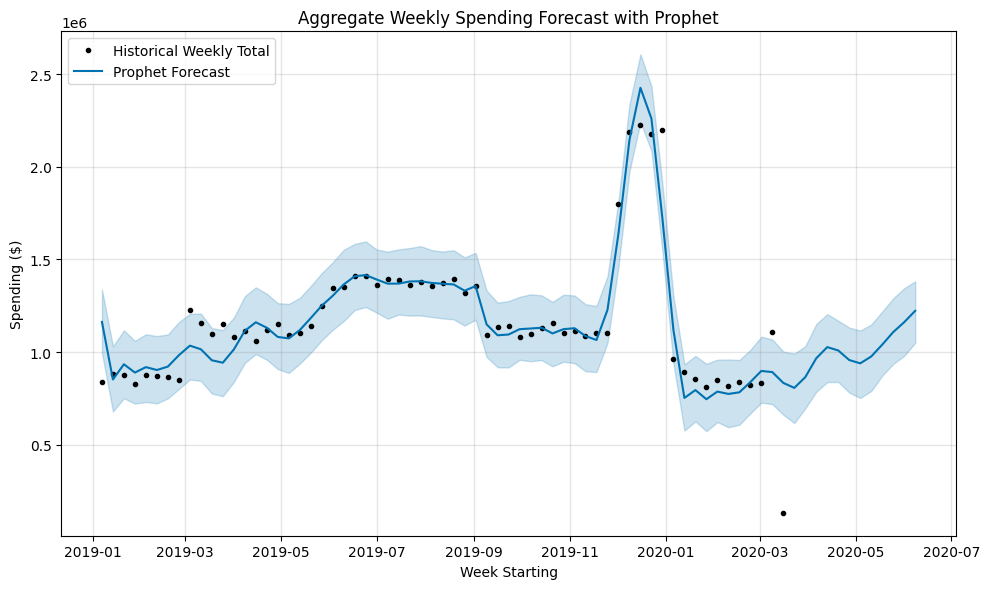

Prophet Test R²: 0.6459078663567718
Prophet Test MAE: 170968.91697663275


In [39]:
# Aggregate weekly series
weekly_total = (
    df.set_index('trans_date_trans_time')['amt']
      .resample('W-MON')
      .sum()
      .reset_index()
      .rename(columns={'trans_date_trans_time':'ds','amt':'y'})
)
# Fit Prophet
m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
m.add_country_holidays(country_name='US')
m.fit(weekly_total)

# Forecast next 12 weeks
future = m.make_future_dataframe(periods=12, freq='W-MON')
forecast = m.predict(future)

# Plot
fig = m.plot(forecast)
ax = fig.gca()
ax.legend(['Historical Weekly Total', 'Prophet Forecast'], loc='upper left')

plt.title('Aggregate Weekly Spending Forecast with Prophet')
plt.xlabel('Week Starting')
plt.ylabel('Spending ($)')
plt.tight_layout()
plt.show()

# Evaluate on held-out period
hist = weekly_total.set_index('ds')['y']
pred = forecast.set_index('ds')['yhat'].loc[hist.index[-len(future):]]
test_idx = hist.index[-12:]
print("Prophet Test R²:", r2_score(hist.loc[test_idx], pred.loc[test_idx]))
print("Prophet Test MAE:", mean_absolute_error(hist.loc[test_idx], pred.loc[test_idx]))


# Recommendations based on best model

In [40]:
# Aggregate spending
agg = df.pivot_table(index='customer_id', columns='category', values='amt', aggfunc='sum', fill_value=0)
agg['Total'] = agg.sum(axis=1)

# Use Prophet for forecast
next_totals = {}
for cid in agg.index:
    temp = df[df['customer_id'] == cid][['trans_date_trans_time', 'amt']].copy()
    temp = temp.set_index('trans_date_trans_time').resample('W-MON').sum().reset_index()
    temp.columns = ['ds', 'y']
    if len(temp) >= 12:
        model = Prophet(weekly_seasonality=True)
        model.fit(temp)
        future = model.make_future_dataframe(periods=4, freq='W-MON')
        forecast = model.predict(future)
        next_total = forecast['yhat'][-4:].sum()
    else:
        next_total = temp['y'].sum()
    next_totals[cid] = next_total

agg['Next_Total'] = pd.Series(next_totals)

benchmarks = {'Rent':0.33, 'Groceries':0.10, 'Utilities':0.05}

# Budget Recommendation UI
def generate_budget(income, rec_pcts, adjustments={}):
    pcts = rec_pcts.copy()
    pcts.update(adjustments)
    factor = 1 / sum(pcts.values())
    return {c: income * (pct * factor) for c, pct in pcts.items()}

def get_float(prompt, min_value=None, max_value=None):
    """Prompt until a float within [min_value, max_value] is input."""
    while True:
        try:
            val = float(input(prompt))
        except ValueError:
            print("Please enter a valid number.")
            continue
        if min_value is not None and val < min_value:
            print(f"Value must be at least {min_value}.")
            continue
        if max_value is not None and val > max_value:
            print(f"Value must be at most {max_value}.")
            continue
        return val

# Interactive Input
income = get_float(
    "\nEnter your monthly take-home pay: $",
    min_value=0.01
)

save_goal = get_float(
    "Desired saving % (0–1): ",
    min_value=0.0,
    max_value=1.0
)

invest_goal = get_float(
    "Desired investing % (0–1): ",
    min_value=0.0,
    max_value=1.0
)

# Ensure don’t exceed 100% total
while save_goal + invest_goal > 1.0:
    print("  → The sum of saving% and investing% must not exceed 1.0 (100%).")
    save_goal = get_float(
        "  Desired saving % (0–1): ",
        min_value=0.0,
        max_value=1.0
    )
    invest_goal = get_float(
        "  Desired investing % (0–1): ",
        min_value=0.0,
        max_value=1.0
    )

rec = benchmarks.copy()
rec['Savings'] = save_goal
rec['Investing'] = invest_goal
rec['Discretionary'] = 1.0 - sum(rec.values())

# Generate plans
candidates = [
    ('Base Plan', generate_budget(income, rec)),
    ('More Groceries', generate_budget(income, rec, {
        'Groceries': rec['Groceries'] + 0.05,
        'Discretionary': rec['Discretionary'] - 0.05
    }))
]

print("\nRecommended Budgets:")
for name, budg in candidates:
    print(f" • {name}:")
    for c, amt in budg.items():
        print(f"    {c}: ${amt:.2f}")
    print()

05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:22 - cmdstanpy - INFO - Chain [1] done processing
05:07:22 - cmdstanpy - INFO - Chain [1] start processing
05:07:23 - cmdstanpy - INFO - Chain [1]


Recommended Budgets:
 • Base Plan:
    Rent: $660.00
    Groceries: $200.00
    Utilities: $100.00
    Savings: $400.00
    Investing: $200.00
    Discretionary: $440.00

 • More Groceries:
    Rent: $660.00
    Groceries: $300.00
    Utilities: $100.00
    Savings: $400.00
    Investing: $200.00
    Discretionary: $340.00

